In [86]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 5

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
3,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3
4,474,5 Ave & E 29 St,40.745168,-73.986831,432,E 7 St & Avenue A,40.726218,-73.983799,20197,Subscriber,1977.0,1,2015-01-01 00:05:00,2015-01-01 00:21:00,16


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [96]:
%%duckdb -o regression_data

WITH raw AS (
    SELECT
        bikeid,
        strptime(
            starttime,
            ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']
        ) AS start_at,
        tripduration / 60.0 AS duration_min,
        "start station latitude" AS lat1,
        "start station longitude" AS lon1,
        "end station latitude" AS lat2,
        "end station longitude" AS lon2
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    WHERE tripduration BETWEEN 60 AND 7200
), features AS (
    SELECT
        duration_min,
        extract('hour' FROM start_at)::INTEGER AS hour_of_day,
        extract('dow' FROM start_at)::INTEGER AS day_of_week,
        CASE
            WHEN extract('dow' FROM start_at) IN (0, 6) THEN 1
            ELSE 0
        END AS is_weekend,

        2 * 6371.0088 * asin(sqrt(
            pow(sin(radians(lat2 - lat1) / 2), 2)
            + cos(radians(lat1)) * cos(radians(lat2))
            * pow(sin(radians(lon2 - lon1) / 2), 2)
        )) AS distance_km,
        -- Kuzey-güney ve doğu-batı bileşenlerinin toplamı
        6371.0088 * abs(radians(lat2 - lat1))
        + 6371.0088
          * cos(radians((lat1 + lat2) / 2))
          * abs(radians(lon2 - lon1)) AS manhattan_distance_km
    FROM raw
)
SELECT
    duration_min,
    hour_of_day,
    day_of_week,
    is_weekend,
    distance_km,
    manhattan_distance_km
FROM features
WHERE distance_km BETWEEN 0 AND 25
USING SAMPLE 1000 ROWS (reservoir, 315);

,duration_min,hour_of_day,day_of_week,is_weekend,distance_km,manhattan_distance_km
0,13.400000,20,0,1,1.815110,2.382067
1,15.050000,18,6,1,2.565870,3.275961
2,12.766667,9,4,0,1.914919,2.342851
3,13.883333,19,4,0,0.000000,0.000000
4,2.650000,16,2,0,0.374358,0.524760
...,...,...,...,...,...,...
995,27.800000,10,3,0,2.950879,3.863240
996,3.300000,21,2,0,0.495887,0.699056
997,6.783333,13,3,0,0.926849,1.023042
998,6.716667,16,3,0,1.273681,1.420105


In [97]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import duckdb

sorgu = """
SELECT 
    date_diff('minute', start_at, stop_at) AS duration_min,
    EXTRACT(HOUR FROM start_at) AS hour_of_day,
    EXTRACT(DOW FROM start_at) AS day_of_week, 
    CASE WHEN EXTRACT(DOW FROM start_at) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend,
    6371 * 2 * ASIN(SQRT(
        POWER(SIN(RADIANS("end station latitude" - "start station latitude") / 2), 2) +
        COS(RADIANS("start station latitude")) * COS(RADIANS("end station latitude")) *
        POWER(SIN(RADIANS("end station longitude" - "start station longitude") / 2), 2)
    )) AS haversine_distance_km,
    SQRT(POWER("end station latitude" - "start station latitude", 2) + POWER("end station longitude" - "start station longitude", 2)) AS euclidean_distance,
    ABS("end station latitude" - "start station latitude") + ABS("end station longitude" - "start station longitude") AS manhattan_distance,
    1 AS model_bias,
    EXTRACT(YEAR FROM start_at) - "birth year" AS user_age
FROM (
    SELECT 
        *,
        strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
        strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
WHERE date_diff('minute', start_at, stop_at) > 0
LIMIT 50000; -- Modelin daha hızlı eğitilmesi için rastgele 50 bin satırla sınırlayabiliriz.
"""

df = duckdb.query(sorgu).to_df()

df = df.dropna()

y = df['duration_min']

X = df[['hour_of_day', 'day_of_week', 'is_weekend', 
        'haversine_distance_km', 'euclidean_distance', 'manhattan_distance', 
        'model_bias', 'user_age']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = sm.OLS(y_train, X_train).fit()

print("\n MODEL ÖZETİ")
print(model.summary())

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- UNBIASED PERFORMANS SONUÇLARI (Test Verisi Üzerinde) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} dakika")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} dakika")
print("Açıklama: Modelimiz daha önce hiç görmediği bir bisiklet sürüşünün süresini ortalama", round(mae,1), "dakika hata ile tahmin etmektedir.")



 MODEL ÖZETİ
                            OLS Regression Results                            
Dep. Variable:           duration_min   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     1064.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:46:22   Log-Likelihood:            -1.4966e+05
No. Observations:               38255   AIC:                         2.993e+05
Df Residuals:                   38247   BIC:                         2.994e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
hour_of_day     

In [98]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_data["hour_sin"] = np.sin(
    2 * np.pi * regression_data["hour_of_day"] / 24
)

regression_data["hour_cos"] = np.cos(
    2 * np.pi * regression_data["hour_of_day"] / 24
)

features = [
    "day_of_week",
    "hour_of_day",
    "is_weekend",
    "distance_km",
    "manhattan_distance_km",
    "hour_sin",
    "hour_cos",
]

train, test = train_test_split(
    regression_data,
    test_size=0.20,
    random_state=315,
)

model = LinearRegression(fit_intercept=True).fit(
    train[features],
    train["duration_min"],
)

pred = model.predict(test[features])

print(f"Bias: {model.intercept_:.3f}")
print(f"MAE: {mean_absolute_error(test['duration_min'], pred):.3f} dakika")
print(f"RMSE: {mean_squared_error(test['duration_min'], pred) ** 0.5:.3f} dakika")
print(f"R2: {r2_score(test['duration_min'], pred):.3f}")

Bias: 3.613
MAE: 4.433 dakika
RMSE: 6.797 dakika
R2: 0.477


In [99]:
%%duckdb -o fictional_trips

-- Sabit hash sırasıyla tekrarlanabilir 10 hayali istasyon çifti
WITH stations AS (
    SELECT DISTINCT
        "start station id" AS station_id,
        "start station name" AS station_name,
        "start station latitude" AS lat,
        "start station longitude" AS lon
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    WHERE "start station latitude" BETWEEN 40.5 AND 41.0
      AND "start station longitude" BETWEEN -74.3 AND -73.6
), numbered AS (
    SELECT *, row_number() OVER (ORDER BY hash(station_id, 315)) AS rn
    FROM stations
), pairs AS (
    SELECT
        s.rn AS trip_id,
        s.station_name AS start_name, s.lat AS start_lat, s.lon AS start_lon,
        e.station_name AS end_name, e.lat AS end_lat, e.lon AS end_lon
    FROM numbered s
    JOIN numbered e ON e.rn = s.rn + 10
    WHERE s.rn <= 10
)
SELECT *,
    2 * 6371.0088 * asin(sqrt(
        pow(sin(radians(end_lat - start_lat) / 2), 2) +
        cos(radians(start_lat)) * cos(radians(end_lat)) *
        pow(sin(radians(end_lon - start_lon) / 2), 2)
    )) AS distance_km
FROM pairs;

,trip_id,start_name,start_lat,start_lon,end_name,end_lat,end_lon,distance_km
0,1,Cadman Plaza E & Tillary St,40.695977,-73.990149,E 2 St & 2 Ave,40.725029,-73.990697,3.230761
1,2,E 66 St & Madison Ave,40.768009,-73.968453,Catherine St & Monroe St,40.711174,-73.996826,6.756710
2,3,Nassau Ave & Newell St,40.724813,-73.947526,2 Ave & 9 St,40.672481,-73.993314,6.982874
3,4,State St & Smith St,40.689269,-73.989129,Broadway & W 51 St,40.762288,-73.983362,8.133866
4,5,7 St & 3 Ave,40.672603,-73.989830,Warren St & Court St,40.686371,-73.993833,1.567713
5,6,Old Slip & Front St,40.703799,-74.008387,E 71 St & 2 Ave,40.768175,-73.959103,8.275531
6,7,Fulton St & Clermont Ave,40.684157,-73.969223,E 53 St & Lexington Ave,40.758281,-73.970694,8.243065
7,8,Duane St & Greenwich St,40.717488,-74.010455,6 Ave & 12 St,40.666318,-73.985462,6.067468
8,9,Stagg St & Union Ave,40.708771,-73.950953,Columbus Ave & W 72 St,40.777057,-73.978985,7.951917
9,10,W 13 St & Hudson St,40.739974,-74.005139,Liberty St & Broadway,40.709056,-74.010434,3.466690


In [36]:
import numpy as np
import pydeck as pdk

routes = fictional_trips.copy()
# Hayali yolculuklar: çarşamba günü saat 12:00
routes['day_of_week'] = 3
routes['hour_of_day'] = 12
routes['is_weekend'] = 0
routes['hour_sin'] = np.sin(2 * np.pi * routes['hour_of_day'] / 24)
routes['hour_cos'] = np.cos(2 * np.pi * routes['hour_of_day'] / 24)
routes['predicted_min'] = np.maximum(0, model.predict(routes[features]))
routes['path'] = routes.apply(
    lambda r: [[r['start_lon'], r['start_lat']], [r['end_lon'], r['end_lat']]], axis=1
)

# Hızlıolan yeşil, yavaş olan kırmızı
lo, hi = routes['predicted_min'].min(), routes['predicted_min'].max()
slow_score = (routes['predicted_min'] - lo) / (hi - lo + 1e-9)
routes['color'] = slow_score.apply(
    lambda x: [int(255 * x), int(200 * (1 - x)), 40, 220]
)

layer = pdk.Layer(
    'PathLayer',
    data=routes,
    get_path='path',
    get_color='color',
    get_width=7,
    width_min_pixels=4,
    pickable=True
)

pdk.Deck(
    layers=[layer],
    initial_view_state=pdk.ViewState(latitude=40.73, longitude=-73.98, zoom=11),
    tooltip={
        'html': '<b>{start_name}</b> → <b>{end_name}</b><br/>Tahmin: {predicted_min} dakika'
    },
    map_style='https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'
)

{
  "initialViewState": {
    "latitude": 40.73,
    "longitude": -73.98,
    "zoom": 11
  },
  "layers": [
    {
      "@@type": "PathLayer",
      "data": [
        {
          "color": [
            63,
            150,
            40,
            220
          ],
          "day_of_week": 3,
          "distance_km": 3.230761451919426,
          "end_lat": 40.72502876,
          "end_lon": -73.99069656,
          "end_name": "E 2 St & 2 Ave",
          "hour_cos": -1.0,
          "hour_of_day": 12,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "path": [
            [
              -73.99014892,
              40.69597683
            ],
            [
              -73.99069656,
              40.72502876
            ]
          ],
          "predicted_min": 21.017263241561025,
          "start_lat": 40.69597683,
          "start_lon": -73.99014892,
          "start_name": "Cadman Plaza E & Tillary St",
          "trip_id": 1
        },
        {
          "color": [
            197,
            45,
            40,
            220
          ],
          "day_of_week": 3,
          "distance_km": 6.756710063003159,
          "end_lat": 40.71117444,
          "end_lon": -73.99682619,
          "end_name": "Catherine St & Monroe St",
          "hour_cos": -1.0,
          "hour_of_day": 12,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "path": [
            [
              -73.96845281124115,
              40.76800889305947
            ],
            [
              -73.99682619,
              40.71117444
            ]
          ],
          "predicted_min": 39.35059105742009,
          "start_lat": 40.76800889305947,
          "start_lon": -73.96845281124115,
          "start_name": "E 66 St & Madison Ave",
          "trip_id": 2
        },
        {
          "color": [
            205,
            38,
            40,
            220
          ],
          "day_of_week": 3,
          "distance_km": 6.9828741773642005,
          "end_lat": 40.6724811,
          "end_lon": -73.99331394,
          "end_name": "2 Ave & 9 St",
          "hour_cos": -1.0,
          "hour_of_day": 12,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "path": [
            [
              -73.94752621650696,
              40.724812564400175
            ],
            [
              -73.99331394,
              40.6724811
            ]
          ],
          "predicted_min": 40.5265415054018,
          "start_lat": 40.724812564400175,
          "start_lon": -73.94752621650696,
          "start_name": "Nassau Ave & Newell St",
          "trip_id": 3
        },
        {
          "color": [
            249,
            4,
            40,
            220
          ],
          "day_of_week": 3,
          "distance_km": 8.133865714302914,
          "end_lat": 40.76228826,
          "end_lon": -73.98336183,
          "end_name": "Broadway & W 51 St",
          "hour_cos": -1.0,
          "hour_of_day": 12,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "path": [
            [
              -73.98912867,
              40.68926942
            ],
            [
              -73.98336183,
              40.76228826
            ]
          ],
          "predicted_min": 46.51117358246748,
          "start_lat": 40.68926942,
          "start_lon": -73.98912867,
          "start_name": "State St & Smith St",
          "trip_id": 4
        },
        {
          "color": [
            0,
            200,
            40,
            220
          ],
          "day_of_week": 3,
          "distance_km": 1.56771306701023,
          "end_lat": 40.686371,
          "end_lon": -73.99383324,
          "end_name": "Warren St & Court St",
          "hour_cos": -1.0,
          "hour_of_day": 12,
          "hour_sin": 1.2246467991473532e-16,
          "is_weekend": 0,
          "path": [
            [
              -73.98983001708984,
      

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [40]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


In [100]:
%%duckdb -o gender_speed

WITH raw AS (
    SELECT
        gender,
        bikeid,
        strptime(
            starttime,
            [
                '%m/%d/%Y %H:%M',
                '%m/%d/%Y %H:%M:%S',
                '%Y-%m-%d %H:%M:%S'
            ]
        ) AS start_at,
        tripduration / 3600.0 AS duration_hours,
        "start station latitude" AS lat1,
        "start station longitude" AS lon1,
        "end station latitude" AS lat2,
        "end station longitude" AS lon2
    FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    WHERE gender IN (1, 2)
      AND tripduration BETWEEN 60 AND 7200
),
speeds AS (
    SELECT
        gender,
        (
            2 * 6371.0088 * asin(
                sqrt(
                    pow(sin(radians(lat2 - lat1) / 2), 2)
                    + cos(radians(lat1))
                    * cos(radians(lat2))
                    * pow(sin(radians(lon2 - lon1) / 2), 2)
                )
            )
        ) / duration_hours AS speed_kmh,
        CASE
            WHEN abs(hash(bikeid, start_at)) % 10 < 8 THEN 'train'
            ELSE 'test'
        END AS split
    FROM raw
)
SELECT *
FROM speeds
WHERE speed_kmh BETWEEN 1 AND 40
USING SAMPLE 3000 ROWS (reservoir, 315);

,gender,speed_kmh,split
0,1,9.185082,train
1,1,9.730185,train
2,1,7.063175,train
3,1,9.669426,train
4,1,7.125287,test
...,...,...,...
2934,2,6.298883,train
2935,1,14.245456,test
2936,1,8.250310,test
2937,1,10.027917,test


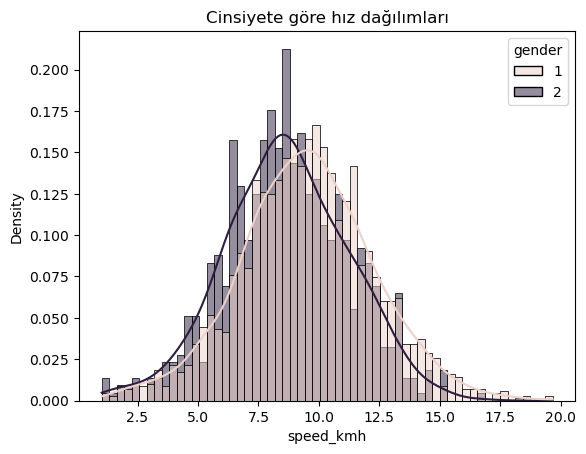

Accuracy: 0.743


In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score
sns.histplot(data=gender_speed, x='speed_kmh', hue='gender', stat='density', common_norm=False, kde=True, bins=60)
plt.title('Cinsiyete göre hız dağılımları')
plt.show()
train_g = gender_speed[gender_speed['split'] == 'train']
test_g = gender_speed[gender_speed['split'] == 'test']
gnb = GaussianNB().fit(train_g[['speed_kmh']], train_g['gender'])
gender_pred = gnb.predict(test_g[['speed_kmh']])
print(f'Accuracy: {accuracy_score(test_g["gender"], gender_pred):.3f}')